# Ising models and Metropolis algorithm

:::{admonition} **What you will learn**

- **Ising Model** as a minimal lattice model for studying phase transitions, defined by spin–spin coupling $J$ and external field $h$.
- **Thermodynamic observables** from simulations: magnetization, energy, heat capacity $C_V$, and susceptibility $\chi$.
- **Why plain MC fails** for many-body systems — most microstates contribute negligibly to the Boltzmann distribution.
- **Master equation and detailed balance** — the theoretical foundation ensuring MCMC converges to the correct equilibrium distribution.
- **Metropolis algorithm** — a practical MCMC scheme: propose a spin flip, accept/reject based on the Boltzmann factor $e^{-\beta \Delta E}$.
- **Autocorrelation functions** — diagnosing how many MC steps are needed for independent samples.

:::

### Ising model

:::{admonition} **Ising Model**
:class: important

$${H([s]) = - \sum_{<ij>} J s_i s_j - h \sum_i s_i}$$

$${Z = \sum_{[s]} e^{-H([s])/k_B T}}$$

- Each spin variable takes values $s_i = \pm 1$
- $[s] = [s_1, s_2, \dots]$ denotes a microstate defined by the configuration of all spins  
- Parameters of the Ising model: $h$ is the external magnetic field, and $J$ is the spin–spin coupling strength  
- The summation $<ij>$ is over **nearest-neighbor** spin pairs

:::

#### Microstates of Ising model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

spins = np.random.choice([-1,1],size=(8,8)) # every time you sammple a new microstate

print(spins)

plt.imshow(spins)

### Sampling microstates of Ising Model

- **Monte Carlo** approach to computing observables is simple: all we have to do is sample from the exponential distribution.

$$P(E_i)= \frac{e^{-\beta E_i}}{\sum_i e^{-\beta E_i}}$$

$$\langle A\rangle = \sum_i A_iP(E_i) \approx\frac{1}{N}\sum_{i=1}^N \underbrace{A_i}_{{\rm chosen}\ {\rm acc.}\ {\rm to}\ P(E_i)}$$

- **Problems with regular MC**
    - There is an astronomical number of states, $i = 1... N^2$! 
    - Most of these microstates make exponentially small contribution to probability distribution! $P(E_i)$
    - Brute force MC will not be efficient for sampling important portions of $P(E_i)$.


### Extracting thermodynamics from Ising models

#### Mangetization 

- Magnetization $M$ or magnetization per spin measures the net alignment of spins.

$$M([s]) = \sum_i s_i$$

$$m([s]) = \frac{M}{N}$$

#### Free Energy

- We can calculate probability of macrostate defined to include all spin configurations with a fixed value of magnetization $M$.

$$P(M) = \frac{Z(M)}{Z} = \frac{\sum_{[s]} e^{-\beta H([s])} \, \delta(M - M([s]))}{Z}$$

- From this, we can compute the **free energy** as a function of magnetization $M$

$$F(M) = -\beta^{-1} \log Z(M) + const$$

- This magnetization-dependent free energy tells us about the relative stability and likelihood of different magnetization states in the system. 
- If there are multiple coexisting phases we will expect to see multiple minima!


#### Response functions 

To quantify **fluctuations** in energy and magnetization, we compute the following **response functions**:

- **Heat capacity**, $C_V$, measures energy fluctuations:

$$C_V(T) = \left( \frac{\partial \langle E \rangle}{\partial T} \right)_V = \frac{1}{k_B T^2} \left( \langle E^2 \rangle - \langle E \rangle^2 \right)$$

- **Magnetic susceptibility**, $\chi_T$, measures magnetization fluctuations in response to an external field $B$:

$$\chi_T = \left( \frac{\partial \langle M \rangle}{\partial B} \right)_T = \frac{1}{k_B T} \left( \langle M^2 \rangle - \langle M \rangle^2 \right)$$

- These response functions become particularly important near critical points, where fluctuations are enhanced, and $C_V$ and $\chi_T$ may diverge in the thermodynamic limit.


### Enforcing periodic boundary conditions

- In the **Ising model with periodic boundary conditions**, the **modulo operation** is used to wrap around the edges of the lattice—so that spins on one edge interact with those on the opposite edge. 
- This effectively turns a 2D grid into a torus (doughnut shape), avoiding edge effects and mimicking an infinite system.

- Consider a 2D lattice of size $ L \times L $. For a site at position $ (i, j) $, its **right neighbor** is at $ (i, j+1) $. But if $ j = L - 1 $, then $ j+1 $ exceeds the lattice. To **wrap around**, we use:

$$
j_{\text{right}} = (j + 1) \mod L
$$

- This brings the index back to $ 0 $ when it exceeds $ L - 1 $.


In [ ]:
L = 10  # Lattice size
spins = np.random.choice([-1,1], size=(L, L))

i, j = 3, 9  # Current spin

# Neighbors with periodic boundary conditions
right = spins[i][(j + 1) % L]
left  = spins[i][(j - 1) % L]
up    = spins[(i - 1) % L][j]
down  = spins[(i + 1) % L][j]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a color map: default to gray, highlight tagged spin and neighbors
color_map = np.full((L, L), 0.5)  # Gray background

# Highlight neighbors (green) and tagged spin (red)
color_map[i, j] = 1.0  # Red for the tagged spin

color_map[i, (j + 1) % L] = 0.2  # Green-ish
color_map[i, (j - 1) % L] = 0.2
color_map[(i - 1) % L, j] = 0.2
color_map[(i + 1) % L, j] = 0.2

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(color_map, cmap="coolwarm", origin="upper", vmin=0, vmax=1)

# Overlay spin values
for x in range(L):
    for y in range(L):
        spin = spins[x, y]
        ax.text(y, x, f"{spin}", ha='center', va='center', color='black', fontsize=10)

# Grid and labels
ax.set_xticks(np.arange(L))
ax.set_yticks(np.arange(L))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_title(f"Tagged spin at ({i}, {j}) and its neighbors", fontsize=12)
ax.grid(False)

plt.tight_layout()
plt.show()


In [ ]:
def get_dE(spins, i, j, J=1, B=0):
    '''Compute change in energy of 2D spin lattice 
    after flipping a spin at a location (i,j)''' 
    
    N = len(spins)
    
    z  = spins[(i+1)%N, j] + spins[(i-1)%N, j] + \
             spins[i, (j+1)%N] + spins[i, (j-1)%N] 
             
    dE = 2*spins[i,j]*(J*z + B)
    
    return dE

### Generating chains! Master Equation and Detailed Balance

**Independent (plain MC) vs. Markov chain sampling**

- In plain MC, each sample $X_i$ is drawn independently — uncorrelated samples converge fast by CLT, but most samples miss the important regions of configuration space.

- In MCMC, each sample $X_{i+1}$ is generated from $X_i$ via a **transition probability** $T_{X'X} = P(X'|X)$. This introduces correlations (slower convergence per sample), but the chain naturally gravitates toward high-probability regions — a huge net win for many-body systems.

$$P(X_N, \dots, X_1) = P_1(X_1) \prod_{i=1}^{N-1} T(X_{i+1} | X_i)$$

- Probability of being at $X$ at $t+\Delta t$ given a prior state at $(X',t)$ can be written in terms of $T_{XX'}$ as:

$$P(X, t+\Delta t) = \sum_{X'}  T_{XX'} P(X', t)$$

- Subtracting P(X,t) from both states we can obtain equation of motion for Markov chain.

$$P(X, t+\Delta t) -P(X,t)= \sum_{X'}  T_{XX'} P(X', t) - P(X, t)\sum_{X'} T_{X'X}$$

- Defining **transition rates** as the limit of $w_{X'X} = lim_{\Delta t \rightarrow 0}\frac{T_{X'X} (\Delta t)}{\Delta t}$ we arrive at the master equation"

:::{admonition} **Master equation: A continuity equation in probability space.**
:class: important

$$\frac{\partial P(X,t)}{\partial t} = \sum_{X'}  w_{X X'} P(X', t) - \sum_{X'} w_{X' X} P(X, t)$$



:::


From master equation we see that in order to reach equilibrium probability must stop depending on time. There are two possibilities:


$$\frac{\partial P(X,t)}{\partial t}  = \sum_{X'} P(X', t) w_{XX'} - \sum_{X'} P(X, t) w_{X' X}=0$$

- When the sum is equal to zero because influx and outflux of probabiity currents cancel each out. This corresponds to steady state condition and is not true equilibrium for there are macroscopic fluxes in the system.
- When every single pairs is identically zero, this is known as detailed balance condition which is equivalent to thermodynamic equilibrium. 



:::{admonition} **Detailed Balance $\equiv$ Condition for equilibrium**

$${  w_{ij}\cdot p_j =  w_{ji} \cdot p_i  }$$

:::

**Master equation for a two state dynamics**

$$\frac{dP(x_1,t)}{dt} = w_{12} p_2 - w_{21} p_1$$

$$\frac{dP(x_2,t)}{dt} = w_{21} p_1  -  w_{12} p_2$$

- In the equilibrium we see that equilibrium is established when probability ratio matches the ratio of tranistions $\frac{p_1}{p_2} = \frac{w_{12}}{w_{21}}$
- In the $NVT$ ensemble we have an explicit requirment for transition rates $\frac{p_1}{p_2} = e^{-\beta (E_1-E_2)} = \frac{w_{12}}{w_{21}}$

### How to pick the moves for Markov chain?

- Now it is time to consider practical aspects of conducting MCMC. How to pick states and transitions?

$$[transition] =  [accept/reject] \cdot [move]$$

$$T(X' \leftarrow X) = \alpha_{X' X}\cdot A_{X' X} $$

- We have great freedom in picking states and moves as long as we satisfy the detailed balance! E.g as long as the ratio of transition probabilities matches ration of Boltzmann factors!

- The simplest case for move is to pick one spins at random per iteration:

$$\alpha_{X' X} = \frac{1}{L^2}$$ 

- For transitions we adopt criteria that favors our chain to explore low energy (high probability) configurations:

- If $p(X') < p(X),\,\,\,\,$ $A_{X'X}=\frac{p(X')}{p(X)}$
- If $p(X') \geq p(X),\,\,\,$ $A_{X'X}=1$

$$\frac{T_{X'X}}{T_{XX'}} = \frac{1/L^2}{1/L^2} \cdot \frac{p(X')/p(X)}{1}$$

:::{admonition} **Metropolis algorithm**
:class: tip


**${ i. \ Initialization.}$**  
Generate an initial spin configuration $[s_0] = (s_1, \dots, s_N)$, either by assigning all spins the same value or choosing each spin randomly as $ +1 $ or $ -1 $.

**${ ii. \ Attempt\ spin\ flip.}$**  
Randomly select a spin and flip it (i.e., multiply by $-1$). This produces a trial configuration $[s_1]$.



**${iii. \ Accept/Reject\ move.}$**  
Compute the energy difference between the trial and original configurations:  

$$\Delta E = E_1 - E_0$$

Determine the acceptance probability:  

$$w = \frac{P[s_1]}{P[s_0]} = \exp(-\beta \Delta E)$$

Generate a random number $ r \in [0, 1] $ and apply the Metropolis criterion:

- **(a)** If $ r \leq w $, accept the move: set $ [s_0] \leftarrow [s_1] $
- **(b)** If $ r > w $, reject the move: retain $ [s_0] $

Return to step **ii** to continue sampling.

:::

### Metropolis in Action: the Müller-Brown Surface

- Before applying Metropolis to the Ising model, let's build intuition on a continuous 2D energy landscape.
- The **Müller-Brown potential** is a classic test surface in computational chemistry with three minima and two saddle points:

$$
V(x,y) = \sum_{k=1}^{4} A_k \exp\!\Big[a_k(x - x_k^0)^2 + b_k(x - x_k^0)(y - y_k^0) + c_k(y - y_k^0)^2\Big]
$$

- It mimics a molecular free energy landscape with multiple metastable states separated by barriers.
- By running Metropolis at different temperatures, we can see how thermal fluctuations help the system **cross barriers** and explore all minima.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke

# ── Müller-Brown potential ──────────────────────────────────────
A  = np.array([-200, -100, -170,  15])
a  = np.array([  -1,   -1, -6.5, 0.7])
b  = np.array([   0,    0,   11, 0.6])
c  = np.array([ -10,  -10, -6.5, 0.7])
x0 = np.array([   1,    0, -0.5, -1 ])
y0 = np.array([   0,  0.5,  1.5,  1 ])

def muller_brown(x, y):
    """Müller-Brown potential energy surface."""
    V = 0.0
    for k in range(4):
        V += A[k] * np.exp(a[k]*(x - x0[k])**2 
                         + b[k]*(x - x0[k])*(y - y0[k]) 
                         + c[k]*(y - y0[k])**2)
    return V

# ── Metropolis sampler on any 2D potential ──────────────────────
def metropolis_2d(V, N=200000, beta=0.02, delta=0.15, start=(-0.5, 1.5)):
    """Metropolis sampling on a 2D potential V(x,y)."""
    samples = np.zeros((N, 2))
    samples[0] = start
    n_accept = 0

    for i in range(1, N):
        xy_old = samples[i - 1]
        xy_new = xy_old + np.random.uniform(-delta, delta, size=2)

        dV = V(xy_new[0], xy_new[1]) - V(xy_old[0], xy_old[1])

        if dV < 0 or np.random.rand() < np.exp(-beta * dV):
            samples[i] = xy_new
            n_accept += 1
        else:
            samples[i] = xy_old

    return samples, n_accept / N

# ── Energy surface on a grid ───────────────────────────────────
xg = np.linspace(-1.7, 1.2, 300)
yg = np.linspace(-0.5, 2.2, 300)
X, Y = np.meshgrid(xg, yg)
Z = muller_brown(X, Y)
Z_clip = np.clip(Z, -200, 100)  # clamp for visualization

# ── Plot the bare energy surface ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
cont = ax.contourf(X, Y, Z_clip, levels=40, cmap='RdYlBu_r')
ax.contour(X, Y, Z_clip, levels=15, colors='k', linewidths=0.4, alpha=0.5)
plt.colorbar(cont, ax=ax, label='$V(x,y)$')

# Mark the three minima
minima = [(-0.558, 1.442), (0.623, 0.028), (-0.050, 0.467)]
labels = ['A (global)', 'B', 'C']
for (mx, my), lbl in zip(minima, labels):
    ax.plot(mx, my, 'w*', markersize=14, markeredgecolor='k', markeredgewidth=0.8)
    ax.annotate(lbl, (mx, my), textcoords="offset points", xytext=(8, 8),
                fontsize=12, fontweight='bold', color='white',
                path_effects=[withStroke(linewidth=2, foreground='black')])

ax.set_xlabel('$x$', fontsize=14)
ax.set_ylabel('$y$', fontsize=14)
ax.set_title('Müller-Brown Potential Energy Surface', fontsize=15)
plt.tight_layout()
plt.show()

#### Temperature controls barrier crossing

- At **low temperature** (high $\beta$), the chain gets trapped in one basin — it rarely has enough "thermal energy" to cross the barrier.
- At **high temperature** (low $\beta$), the chain moves freely across all basins, sampling the full landscape.
- This is the same physics that governs protein folding, chemical reactions, and phase transitions!

In [ ]:
# ── MCMC at three temperatures ──────────────────────────────────
betas  = [0.1,  0.02,  0.005]
labels_T = ['Low $T$\n($\\beta=0.1$)', 'Medium $T$\n($\\beta=0.02$)', 'High $T$\n($\\beta=0.005$)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, beta, lab in zip(axes, betas, labels_T):
    samples, acc = metropolis_2d(muller_brown, N=300000, beta=beta, delta=0.15)
    burn = 10000
    s = samples[burn:]

    # Energy contours
    ax.contourf(X, Y, Z_clip, levels=30, cmap='RdYlBu_r', alpha=0.6)
    ax.contour(X, Y, Z_clip, levels=12, colors='k', linewidths=0.3, alpha=0.4)

    # MCMC trajectory (thin subsample for clarity)
    ax.plot(s[::20, 0], s[::20, 1], '-', color='black', lw=0.15, alpha=0.4)

    # 2D sampled density via hexbin
    ax.hexbin(s[:, 0], s[:, 1], gridsize=50, cmap='hot_r', alpha=0.55, mincnt=1)

    # Mark minima
    for (mx, my) in minima:
        ax.plot(mx, my, 'w*', markersize=12, markeredgecolor='k', markeredgewidth=0.7)

    ax.set_xlim(-1.7, 1.2)
    ax.set_ylim(-0.5, 2.2)
    ax.set_xlabel('$x$', fontsize=13)
    ax.set_ylabel('$y$', fontsize=13)
    ax.set_title(f'{lab}\nacc = {acc:.2f}', fontsize=13)

plt.suptitle('Metropolis Sampling on the Müller-Brown Surface', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# ── Trace plots: watching the chain explore ─────────────────────
samples, acc = metropolis_2d(muller_brown, N=200000, beta=0.02, delta=0.15)

# Compute energy along the trajectory
E_trace = np.array([muller_brown(s[0], s[1]) for s in samples])

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(samples[:, 0], lw=0.3, color='steelblue')
axes[0].set_ylabel('$x$', fontsize=13)
axes[0].set_title(f'Metropolis on Müller-Brown ($\\beta=0.02$, acc={acc:.2f})', fontsize=14)

axes[1].plot(samples[:, 1], lw=0.3, color='darkorange')
axes[1].set_ylabel('$y$', fontsize=13)

axes[2].plot(E_trace, lw=0.3, color='crimson')
axes[2].set_ylabel('$V(x,y)$', fontsize=13)
axes[2].set_xlabel('MC step', fontsize=13)

for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

#### From samples to a free energy profile

The Müller-Brown surface is a **potential** $V(x,y)$. What the experimentalist usually cares about is the **free energy** along some reaction coordinate $q$ — the potential of mean force with the other degrees of freedom integrated out:

$$
F(q) = -k_B T \ln p(q), \qquad p(q) = \int dx\,dy\; e^{-\beta V(x,y)}\,\delta\!\big(q - q(x,y)\big)
$$

Since our Metropolis chain samples $(x_i,y_i) \sim p(x,y) \propto e^{-\beta V}$, the projected density $p(q)$ is just a **histogram** of $q(x_i,y_i)$. Taking $q = x$ gives a 1D profile we can read by eye.

Two ideas worth pausing on:

- **$V$ and $F$ are not the same thing.** Well *depths* in $F(x)$ differ from well depths in $V$ because entropy reshapes them — a wide shallow basin can dominate a narrow deep one. $F = U - TS$ made concrete.
- **This is exactly umbrella sampling / WHAM / metadynamics — in its honest form.** Everything fancier exists to *force* the histogram to converge when direct MCMC can't cross barriers fast enough.


In [ ]:
# Medium T: the chain crosses all three wells, so the histogram converges
# and F(x) = -kT ln p(x) is a reliable projection of the free energy.
beta = 0.05
samples, acc = metropolis_2d(muller_brown, N=500_000, beta=beta, delta=0.15)
burn = 20_000
x = samples[burn:, 0]

# Histogram -> density -> -kT ln p
hist, edges = np.histogram(x, bins=120, range=(-1.7, 1.2), density=True)
centers = 0.5 * (edges[1:] + edges[:-1])
F = -np.log(hist + 1e-12) / beta
F -= F.min()   # zero at global minimum

# For comparison, a 'bare potential' curve along y=0 (naive 1D slice)
V_slice = muller_brown(centers, np.zeros_like(centers))
V_slice -= V_slice.min()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(centers, F,       lw=2.0, color='crimson',   label=r'$F(x) = -k_BT\ln p(x)$  (from MCMC)')
ax.plot(centers, V_slice, lw=1.2, color='steelblue', ls='--', label=r'$V(x, y{=}0)$  (1D slice, for reference)')
ax.set_xlabel('$x$'); ax.set_ylabel('energy')
ax.set_title(fr'Free energy profile at $\beta = {beta}$  (acc = {acc:.2f})')
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'bins visited: {(hist > 0).sum()} / {len(hist)}')


##### When $F(q)$ is a lie

- Lower the temperature and the chain gets **stuck** in whichever basin it started in. The histogram is missing entire regions, and $-k_BT\ln p$ in the empty bins diverges. The curve you plot is not the free energy — it's the free energy *of one metastable basin*, masquerading as the whole thing.

- This is the **rare-event problem** in its cleanest form. The reason umbrella sampling, metadynamics, and replica exchange exist is that this failure mode is the default in real molecular simulations, not the exception.


In [ ]:
# Low T: the chain is trapped. Whatever F(x) we read out is missing the
# other basins entirely. Plot the trajectory next to F(x) so the failure
# mode is impossible to miss.
beta_low = 0.2
samples_low, acc_low = metropolis_2d(muller_brown, N=500_000, beta=beta_low, delta=0.15)
x_low = samples_low[burn:, 0]

hist_low, edges_low = np.histogram(x_low, bins=120, range=(-1.7, 1.2), density=True)
centers_low = 0.5 * (edges_low[1:] + edges_low[:-1])
F_low = -np.log(hist_low + 1e-12) / beta_low
F_low -= F_low.min()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: trajectory x(t) -- visibly stuck in one basin
axes[0].plot(samples_low[:, 0], lw=0.3, color='crimson')
axes[0].set_xlabel('MC step'); axes[0].set_ylabel('$x$')
axes[0].set_title(fr'Trapped chain at $\beta = {beta_low}$  (acc = {acc_low:.2f})')
axes[0].set_ylim(-1.7, 1.2); axes[0].grid(alpha=0.3)

# Right: the 'free energy' it produces vs. the reference from the mixing chain
axes[1].plot(centers,     F,     lw=2.0, color='steelblue', label=fr'$F(x)$, $\beta={beta}$ (converged)')
axes[1].plot(centers_low, F_low, lw=2.0, color='crimson',   label=fr'$F(x)$, $\beta={beta_low}$ (trapped)')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel(r'$-k_BT\ln p(x)$')
axes[1].set_title('Same algorithm, two temperatures — one of these is a lie')
axes[1].legend(frameon=False); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'bins visited at beta={beta_low}: {(hist_low > 0).sum()} / {len(hist_low)}')


### Code for running 2D Ising MCMC Simulations

**Design choices:**
- Numba `@njit` kernels for performance — these must be standalone functions (not class methods).
- `run_ising2d` takes `spins` as input so you can **continue from a previous configuration** (needed for annealing, hysteresis, etc.).
- A separate `compute_thermo` helper computes thermodynamic averages with proper burn-in removal.


In [1]:
from numba import njit
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

@njit
def _total_energy(spins, J, B):
    """Total energy of a 2D Ising configuration (no double-counting)."""
    N = spins.shape[0]
    E = 0.0
    for i in range(N):
        for j in range(N):
            S = spins[i, j]
            # Only count right and down neighbors to avoid double-counting
            E -= J * S * (spins[(i+1)%N, j] + spins[i, (j+1)%N])
            E -= B * S
    return E

@njit
def run_ising2d(spins, T, J, B, n_steps, out_freq):
    """
    2D Ising Metropolis MCMC.

    Parameters
    ----------
    spins    : (N, N) int array — initial spin configuration (modified in-place)
    T, J, B  : Temperature, coupling, field
    n_steps  : Number of single-spin-flip attempts
    out_freq : Record observables every out_freq steps

    Returns
    -------
    spins : final configuration (same array, modified in-place)
    S_out : snapshots of spin configs at each output step
    E_out : per-spin energy trace
    M_out : per-spin magnetization trace
    """
    N = spins.shape[0]
    E_t = _total_energy(spins, J, B)
    M_t = float(np.sum(spins))

    n_out = n_steps // out_freq
    S_out = np.empty((n_out, N, N), dtype=np.int8)
    E_out = np.empty(n_out)
    M_out = np.empty(n_out)
    k = 0

    for step in range(n_steps):
        i = np.random.randint(N)
        j = np.random.randint(N)

        S = spins[i, j]
        nn = (spins[(i+1)%N, j] + spins[(i-1)%N, j]
            + spins[i, (j+1)%N] + spins[i, (j-1)%N])
        dE = 2.0 * S * (J * nn + B)

        if dE <= 0 or np.random.rand() < np.exp(-dE / T):
            spins[i, j] = -S
            E_t += dE
            M_t += -2.0 * S

        if step % out_freq == 0:
            S_out[k] = spins
            E_out[k] = E_t / N**2
            M_out[k] = M_t / N**2
            k += 1

    return spins, S_out, E_out, M_out


def init_spins(N, state='random'):
    """Initialize an N x N spin lattice.
    state: 'random', 'up' (+1), or 'down' (-1).
    """
    if state == 'random':
        return np.random.choice(np.array([-1, 1]), size=(N, N)).astype(np.int64)
    elif state == 'up':
        return np.ones((N, N), dtype=np.int64)
    elif state == 'down':
        return -np.ones((N, N), dtype=np.int64)


def compute_thermo(E, M, T, burnin=0.1):
    """Compute thermodynamic averages from E and M traces.
    
    Discards the first `burnin` fraction of data.
    Returns dict with <E>, <M>, Cv, chi.
    """
    idx = int(len(E) * burnin)
    E, M = E[idx:], M[idx:]
    return {
        'E': np.mean(E),
        'M': np.mean(M),
        'Cv': np.var(E) / T**2,
        'chi': np.var(M) / T,
    }


def plot_ising(i, S, E, M):
    """Plot snapshot i alongside E and M traces."""
    fig, ax = plt.subplots(ncols=3, figsize=(12, 4))
    ax[0].pcolormesh(S[i], cmap='coolwarm')
    ax[0].set(ylabel='$i$', xlabel='$j$', aspect='equal')
    ax[1].plot(E, lw=0.5)
    ax[1].axvline(i, color='red', lw=0.8, ls='--')
    ax[1].set(ylabel='$E/N^2$', xlabel='steps')
    ax[2].plot(M, lw=0.5)
    ax[2].axvline(i, color='red', lw=0.8, ls='--')
    ax[2].set(ylabel='$M/N^2$', xlabel='steps')
    fig.tight_layout()
    plt.show()


In [11]:
# Simulation parameters
N = 40
T, J, B = 2.0, 1, 0
n_steps = 1000_000
out_freq = 10

# Initialize and run
spins = init_spins(N, state='random')
spins, S, E, M = run_ising2d(spins, T, J, B, n_steps, out_freq)


In [7]:
print(f'Snapshots: {S.shape},  E trace: {E.shape},  M trace: {M.shape}')


Snapshots: (10000, 40, 40),  E trace: (10000,),  M trace: (10000,)


In [ ]:
widgets.interact(lambda i: plot_ising(i, S, E, M), i=(0, len(E)-1));


interactive(children=(IntSlider(value=49999, description='i', max=99999), Output()), _dom_classes=('widget-int…

### Carry out explorative simulations

- How do we know if the simulation has done enough sampling? How do we assess convergence and errors? 
- Test the dependence of observables on system size.
- Test the dependence of observables on initital conditions.
- Vary intensive parameters, e.g., temperature and field strength. Investigate changes in observables such as magnetization, energy, susceptibility, heat capacity.
- Think about alternative ways of accelerating and enhancing the sampling.

#### Parameter sweeps 

In [13]:
Ts = np.linspace(1, 4, 40)
N = 40
results = {key: [] for key in ['E', 'M', 'Cv', 'chi']}

for T in Ts:
    spins = init_spins(N)
    spins, _, E, M = run_ising2d(spins, T, J=1, B=0, n_steps=1_000_000, out_freq=10)
    th = compute_thermo(E, M, T)
    for key in results:
        results[key].append(th[key])


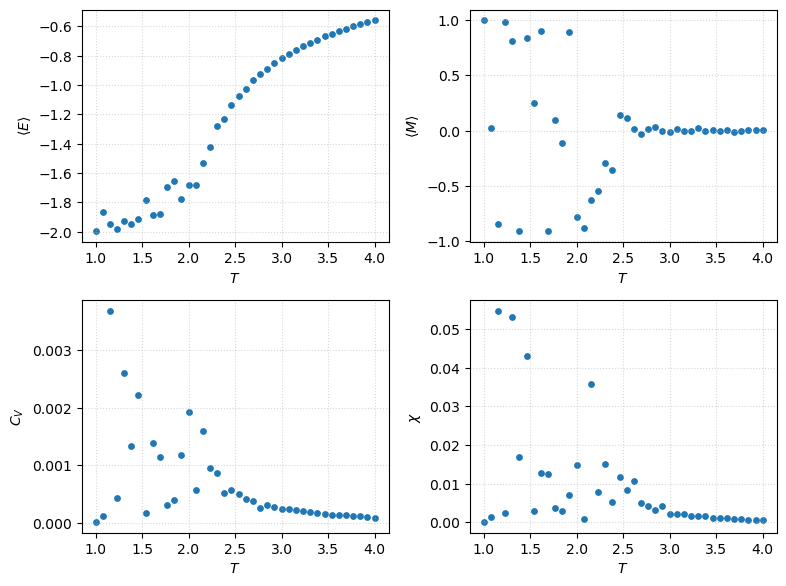

In [14]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(8, 6))

labels = {'E': '$\\langle E \\rangle$', 'M': '$\\langle M \\rangle$',
          'Cv': '$C_V$', 'chi': '$\\chi$'}

for a, key in zip(ax.flat, ['E', 'M', 'Cv', 'chi']):
    a.scatter(Ts, results[key], s=15)
    a.set(xlabel='$T$', ylabel=labels[key])
    a.grid(True, ls=':', alpha=0.5)

fig.tight_layout()


### Autocorrelation functions

- For any observable $A(t)$ along a Markov chain, the (unnormalized) autocorrelation is the lag-$n$ covariance:

$$
C_A(n) = \big\langle \big(A(t) - \langle A \rangle\big)\big(A(t+n) - \langle A \rangle\big) \big\rangle
$$

- Dividing by the variance gives the **normalized** autocorrelation function, with $\rho_A(0) = 1$:

$$
\rho_A(n) = \frac{C_A(n)}{C_A(0)}
= \frac{\big\langle (A(t) - \langle A \rangle)(A(t+n) - \langle A \rangle) \big\rangle}
{\big\langle (A(t) - \langle A \rangle)^2 \big\rangle}
$$

| Observable            | Type                  | Purpose                              |
|-----------------------|-----------------------|--------------------------------------|
| $M(t)$, $E(t)$        | Global observables    | System-wide relaxation               |
| $s_i s_{i+r}$         | Spatial correlation   | Correlation length / criticality     |
| $C(n)$                | General ACF           | Basis for estimating correlation time|


#### Integrated and exponential autocorrelation time

- Once you have $\rho_A(n)$, two numbers summarize it:

- **Integrated autocorrelation time** — controls the statistical error of $\langle A\rangle$:
$$
\tau_{\text{int}} = \frac{1}{2} + \sum_{n=1}^{n_{\text{cut}}} \rho_A(n)
$$
The effective number of independent samples is $N_{\text{eff}} = N / (2\tau_{\text{int}})$, so the true standard error of the mean is $\sigma/\sqrt{N_{\text{eff}}}$ — not $\sigma/\sqrt{N}$. Ignoring $\tau$ makes error bars look artificially tight.

- **Exponential autocorrelation time** — governs the slowest mode and how long burn-in needs to be: $\rho_A(n) \sim \exp(-n/\tau_{\text{exp}})$ for large $n$.

- For a pure exponential, $\tau_{\text{int}} \approx \tau_{\text{exp}}$; in general they differ, and $\tau_{\text{int}}$ is the one that enters error bars.


##### Reading an ACF — a diagnostic checklist

Before trusting any average from a Markov chain, eyeball the ACF and ask:

1. **Does it decay toward zero?** If it plateaus, the chain is non-ergodic on your run length — throw the average away.
2. **How fast?** A short $\tau$ means cheap independent samples; a long $\tau$ means you're paying for correlated ones.
3. **Is $N \gg \tau$?** Rule of thumb: you want at least $\sim 100\,\tau$ samples after burn-in, otherwise error bars are meaningless.
4. **Does the tail look noisy?** The ACF estimator becomes unreliable at large lags; truncate the $\tau_{\text{int}}$ sum with a window proportional to $\tau$ itself (Sokal's automated windowing).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def autocorr(x):
    """Normalized autocorrelation function rho(n) of a 1D series.

    Uses the *biased* estimator (divide by N, not N-k): noisier tail but far
    more stable than the unbiased form — this is what Sokal and most MCMC
    textbooks recommend.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    acf = np.correlate(x, x, mode='full')[-n:] / (x.var() * n)
    return acf

def tau_int_sokal(acf, c=5.0):
    """Integrated autocorrelation time with Sokal's automated windowing.

    Truncates the sum at the first M such that M >= c * tau_int(M).
    Returns (tau_int, window_M).
    """
    tau = 0.5
    for M in range(1, len(acf)):
        tau += acf[M]
        if M >= c * tau:
            return tau, M
    return tau, len(acf) - 1

def tau_exp_fit(acf, n_fit=None):
    """Exponential autocorrelation time by linear fit of log|acf|.

    Fits only up to the first zero-crossing (or n_fit, whichever is smaller)
    to avoid the noisy tail. Returns tau_exp.
    """
    # first zero-crossing
    zc = np.argmax(acf <= 0) if np.any(acf <= 0) else len(acf)
    end = zc if n_fit is None else min(zc, n_fit)
    end = max(end, 3)  # need at least a few points
    lags = np.arange(end)
    log_acf = np.log(acf[:end])
    slope, _ = np.polyfit(lags, log_acf, 1)
    return -1.0 / slope


In [3]:
# Run two simulations: well above Tc and near Tc.
# out_freq=1 so that 'lag' is measured in single-flip steps, not stored frames.
N = 40
n_steps = 200_000

spins_hi = init_spins(N)
_, _, E_hi, M_hi = run_ising2d(spins_hi, T=4.0,  J=1, B=0, n_steps=n_steps, out_freq=1)

spins_cr = init_spins(N)
_, _, E_cr, M_cr = run_ising2d(spins_cr, T=2.27, J=1, B=0, n_steps=n_steps, out_freq=1)

# Discard burn-in (first 10%)
burn = n_steps // 10
M_hi, M_cr = M_hi[burn:], M_cr[burn:]
print(f'T=4.00 : <|M|> = {np.abs(M_hi).mean():.3f}')
print(f'T=2.27 : <|M|> = {np.abs(M_cr).mean():.3f}  (near Tc)')


T=4.00 : <|M|> = 0.050
T=2.27 : <|M|> = 0.252  (near Tc)


In [ ]:
# Three ACFs side by side: white noise, Ising well above Tc, Ising near Tc.
# This is the cleanest on-ramp to 'critical slowing down'.
max_lag = 2000
noise = np.random.randn(len(M_hi))

rho_noise = autocorr(noise)[:max_lag]
rho_hi    = autocorr(M_hi)[:max_lag]
rho_cr    = autocorr(M_cr)[:max_lag]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(rho_noise, lw=1.2, label='white noise',         color='gray')
ax.plot(rho_hi,    lw=1.2, label='Ising, $T=4.0$',      color='steelblue')
ax.plot(rho_cr,    lw=1.2, label='Ising, $T=2.27$ (≈ $T_c$)', color='crimson')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('lag $n$ (single-flip steps)')
ax.set_ylabel(r'$\rho_M(n)$')
ax.set_title('Magnetization autocorrelation: the signature of critical slowing down')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# For each chain, compute tau_int (Sokal) and tau_exp (log-linear fit),
# then compare naive vs autocorrelation-corrected error bars on <M>.
def report(label, M):
    acf = autocorr(M)
    tau_i, window = tau_int_sokal(acf, c=5.0)
    try:
        tau_e = tau_exp_fit(acf)
    except Exception:
        tau_e = float('nan')
    N = len(M)
    N_eff = N / (2 * tau_i)
    mean = M.mean()
    sigma = M.std(ddof=1)
    err_naive = sigma / np.sqrt(N)
    err_true  = sigma / np.sqrt(N_eff)
    print(f'--- {label} ---')
    print(f'  tau_int = {tau_i:7.1f}  (window M = {window})')
    print(f'  tau_exp = {tau_e:7.1f}')
    print(f'  N       = {N}')
    print(f'  N_eff   = {N_eff:7.1f}')
    print(f'  <M>     = {mean:+.4f}')
    print(f'  err (naive, ignoring tau) = {err_naive:.5f}')
    print(f'  err (true,  using tau)    = {err_true:.5f}')
    print(f'  inflation factor          = {err_true/err_naive:.1f}x')
    print()

report('Ising T = 4.0',              M_hi)
report('Ising T = 2.27 (near T_c)',  M_cr)


In [ ]:
# Back to Müller-Brown: the ACF as an ergodicity alarm.
# At low T the chain gets stuck in one basin. Its ACF never decays —
# a clean visual proof that 'long tau' is a warning flag, not just a number.
samples_trap, _ = metropolis_2d(muller_brown, N=200_000, beta=0.1,  delta=0.15)
samples_mix,  _ = metropolis_2d(muller_brown, N=200_000, beta=0.02, delta=0.15)

burn = 10_000
x_trap = samples_trap[burn:, 0]
x_mix  = samples_mix[burn:, 0]

max_lag = 5000
rho_trap = autocorr(x_trap)[:max_lag]
rho_mix  = autocorr(x_mix)[:max_lag]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(rho_trap, color='crimson',   lw=1.2, label=r'low $T$ ($\beta=0.1$) — trapped')
ax.plot(rho_mix,  color='steelblue', lw=1.2, label=r'medium $T$ ($\beta=0.02$) — mixing')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('lag $n$')
ax.set_ylabel(r'$\rho_x(n)$')
ax.set_title('Müller-Brown: a non-decaying ACF diagnoses broken ergodicity')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Problems

#### Problem-1

Revisit the example MCMC simulation for determining $\pi$ value. Vary the size of the displacement to determine the optimal size that generates quickest convergence to the value of $\pi$


#### Problem-2 

Carry out MC simulation of 2D ising spin model for various lattice sizes $N= 16,32, 64$ at temperatures above and below critical e.g $T<T_c$ and $T>T_c$.   

- How long does it take to equilibrate system as a function of size and as a function of T?

- Plot some observables as a function of number of samples states to show that the system is carrying out some sort of random walk in the configurational space. 

- How do profiles of Energy vs T, Magnetization vs T and heat capacity vs T, and susceptibility vs T change as a function of size of our lattice. 

- Does $J>0$ and $J<0$ change the nature of phase transition?

#### Problem-3

Compute correlation functions of spin variable, that is how correlated are spins as a function of distance on a lattice, $L$. $C(L)=\langle s_i s_{i+L}\rangle -\langle s_i\rangle \langle s_{i+L}\rangle $ Make sure to account for the periodic boundary conditions! 

> Note that you can pick a special tagged spin and calculate correlation function of taged spin ($s_13$ for instance) with any other as a function of lattice separation  by averaging over produced MC configurations.  Or you can take advantage of the fact that there are no privileged spins and average over many spins and average over MC configurations e.g $s_1, s_2, ...$. E.g you can pick a horizontal line of spins and run a summation for each fixed r_ab distance. 

#### Problem-4

Take a 20 by 20 lattice and equilibrate the system with a value of external field B equal to +1. 
Now slowly change h to −1 in discrete steps during each of these steps, use the previously equilibrated
configuration as an input to the system to undergo equilibriation again.  

Calculate average and variance quantities (e.g E, M, C etc). Notice anything interesing :)